# UTN SANTA FE - Ciencia de Datos
## Trabajo Práctico 1 - Parte 1: Análisis Exploratorio de Datos

In [ ]:
# Importando las librerías necesarias
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración de estilo básico para que los gráficos se vean más limpios
sns.set_theme(style="whitegrid")

### Carga del Conjunto de Datos
Lectura del archivo `i40 (datos).csv` y visualización de las primeras filas de los equipos industriales.

In [7]:
# Carga de datos
df = pd.read_csv('i40 (datos).csv')
df.columns = df.columns.str.strip()

# Visualización de las primeras 5 filas para comprobar que cargó bien
df.head()

,idx,parent_device_id,product_type,air_temp [K],process_temp [K],speed [RPM],torque [Nm],tool_wear [min],target
0,0,5291,L,303.80,313.30,1406,52.10,166,normal
1,1,3908,L,302.30,311.20,1633,36.40,114,normal
2,2,10767,M,302.27,311.47,1228,68.75,187,failure
3,3,15484,L,302.35,311.93,1522,36.99,214,failure
4,4,784,L,296.70,307.90,1743,27.90,55,normal


### 1. Medidas de Tendencia Central y de Dispersión
Utilizamos el método `describe()` para obtener un resumen estadístico general. Esto nos devuelve la media (tendencia central), la desviación estándar (dispersión), los valores mínimos/máximos y los cuartiles de todas las variables numéricas.

In [8]:
resumen_estadistico = df.describe()
display(resumen_estadistico)

,idx,parent_device_id,air_temp [K],process_temp [K],speed [RPM],torque [Nm],tool_wear [min]
count,14521.000000,14521.000000,14481.000000,14521.000000,14521.000000,14521.000000,14521.000000
mean,7260.000000,9802.076510,300.478975,310.165287,1513.389436,44.955809,124.921700
std,4191.995965,5572.531866,1.952737,1.329586,313.604170,14.226641,70.105992
min,0.000000,0.000000,295.300000,305.700000,-1.000000,3.800000,0.000000
25%,3630.000000,4982.000000,298.900000,309.200000,1354.000000,35.990000,64.000000
50%,7260.000000,9956.000000,300.600000,310.320000,1423.000000,46.700000,127.000000
75%,10890.000000,14624.000000,302.200000,311.090000,1561.000000,55.000000,193.000000
max,14520.000000,19320.000000,304.500000,313.800000,2886.000000,76.600000,253.000000


### 2. Distribuciones
Analizamos mediante histogramas cómo se distribuyen las variables numéricas principales (`air_temp`, `process_temp`, `speed`, `torque`, `tool_wear`).

### 3. Proporciones
Analizamos la proporción de los distintos tipos de productos (`product_type`) y la proporción de registros que presentan una falla (`target`).

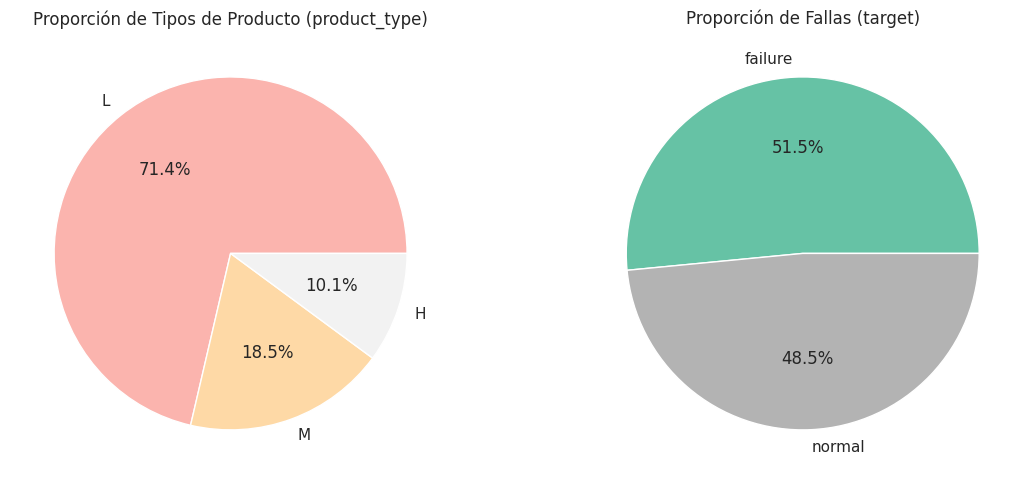

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Gráfico de torta para la proporción de Product Type
df['product_type'].value_counts().plot.pie(autopct='%1.1f%%', ax=axes[0], cmap='Pastel1')
axes[0].set_title('Proporción de Tipos de Producto (product_type)')
axes[0].set_ylabel('')

# Gráfico de torta para la proporción de Fallas (Target)
df['target'].value_counts().plot.pie(autopct='%1.1f%%', ax=axes[1], cmap='Set2')
axes[1].set_title('Proporción de Fallas (target)')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

### 4. Relaciones entre variables
Para encontrar relaciones, primero visualizamos la correlación lineal entre todas las variables numéricas mediante un mapa de calor. Luego, hacemos un gráfico de dispersión específico para ver cómo interactúan la temperatura del aire y la del proceso según si hubo o no una falla